

<h1 style="text-align:center;">TIME SERIES AND ECONOMETRICS</h1>
<h2 style="text-align:center;">NON-STATIONARITY AND EQUILIBRIUM: COINTEGRATION ANALYSIS OF AAPL AND MSFT</h2>



<h3>Student Information</h3>
<p><strong>Prepared by:</strong> [Praise Ruguchu]</p>
<p><strong>Registration Number:</strong> [R2418436]</p>
<p><strong>Course:</strong> Time Series and Econometrics</p>



<h3>Executive Summary</h3>
<p>
This project applies cointegration methodology and Vector Error Correction Model (VECM) 
to model non-stationarity and identify long-run equilibrium relationships between two 
financial time series. Using daily closing prices for Apple Inc. (AAPL) and Microsoft 
Corp. (MSFT) from January 2018 to December 2025, we test for unit roots, examine 
cointegration, estimate the VECM, calibrate parameters, and diagnose model fit.
</p>
<p>
The analysis reveals that while both series are non-stationary, cointegration is 
statistically borderline (p = 0.0604), suggesting the equilibrium relationship is not 
robust over the full sample period. The report concludes with practical deployment 
recommendations for pairs trading and identifies structural breaks as the primary damage.
</p>




<h2>Dataset Selection</h2>

<p>
Out of the three datasets analyzed individually by group members, the <b>AAPL + MSFT</b> pair was selected as the best for the following reasons:
</p>

<p><b>1.</b> Both series are clearly non-stationary (ADF p-values: AAPL = 0.9325, MSFT = 0.9069), satisfying the key precondition for cointegration analysis.</p>

<p><b>2.</b> The pair exhibits borderline cointegration (p = 0.0604), providing a more interesting diagnostic case than a perfectly cointegrated or completely non-cointegrated pair.</p>

<p><b>3.</b> Both stocks belong to the same sector (technology) but have different business models (hardware vs. cloud/software), making the equilibrium relationship theoretically meaningful yet empirically challenging.</p>

<p><b>4.</b> Sufficient data length (2018-2025, ~2,010 observations) allows robust VECM estimation.</p>

<p><b>5.</b> High liquidity and trading volume make the pair suitable for practical pairs trading deployment.</p>



<h2>1. Definition</h2>

<h3><b>Modeling Non-Stationarity and Finding an Equilibrium</b></h3>
<p>
The modeling of non-stationarity and equilibrium involves three interconnected econometric concepts:
</p>

<h3><b>1.1 Non-Stationarity</b></h3>
<p>
A time series is non-stationary if its statistical properties (mean, variance, autocorrelation) change over time. 
The most common form is a unit root process (random walk):
</p>

<p style="text-align:center;">
<i>Y<sub>t</sub> = Y<sub>t−1</sub> + ε<sub>t</sub></i><br>
where ε<sub>t</sub> ~ i.i.d. (0, σ²)
</p>

<p>
This is formalized by the <b>Augmented Dickey-Fuller (ADF) test</b> with the null hypothesis:
</p>

<p><b>H₀:</b> γ = 0 (unit root exists, series is non-stationary)</p>
<p><b>H₁:</b> γ &lt; 0 (no unit root, series is stationary)</p>

<p>Where the test regression is:</p>

<p style="text-align:center;">
<i>ΔY<sub>t</sub> = α + βt + γY<sub>t−1</sub> + Σ δ<sub>i</sub>ΔY<sub>t−i</sub> + ε<sub>t</sub></i>
</p>

<h3><b>1.2 Cointegration (Finding Equilibrium)</b></h3>
<p>
When two or more non-stationary series move together such that a linear combination is stationary, 
they are cointegrated. This linear combination represents the long-run equilibrium relationship.
</p>

<p>
For two series X<sub>t</sub> and Y<sub>t</sub>, the equilibrium is:
</p>

<p style="text-align:center;">
<i>Y<sub>t</sub> = βX<sub>t</sub> + ε<sub>t</sub></i><br>
where ε<sub>t</sub> ~ I(0)
</p>

<p>
The <b>Engle-Granger cointegration test</b> tests:
</p>

<p><b>H₀:</b> No cointegration (residuals are non-stationary)</p>
<p><b>H₁:</b> Cointegration exists (residuals are stationary)</p>

<h3><b>1.3 Vector Error Correction Model (VECM)</b></h3>
<p>
Once cointegration is established, the VECM captures both short-run dynamics and long-run equilibrium adjustment:
</p>

<p style="text-align:center;">
<i>ΔY<sub>t</sub> = αβ′Y<sub>t−1</sub> + Σ Γ<sub>i</sub>ΔY<sub>t−i</sub> + ε<sub>t</sub></i>
</p>



<h2>2. Demonstration</h2>

<h3><b>2.1 Data Acquisition</b></h3>


In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import VECM

# Download data
assets = ['AAPL', 'MSFT']
data = yf.download(assets, start='2018-01-01', end='2025-12-31', auto_adjust=True)
prices = data['Close']

print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Observations: {len(prices)}")

[*********************100%***********************]  2 of 2 completed

Date range: 2018-01-02 to 2025-12-30
Observations: 2010



<h3><b>2.2 Stationarity Testing (ADF)</b></h3>


In [22]:
print("AUGMENTED DICKEY-FULLER TEST (Price Levels)")
print("=" * 50)

for ticker in prices.columns:
    result = adfuller(prices[ticker].dropna(), autolag='AIC')
    print(f"\n{ticker}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  P-Value: {result[1]:.4f}")
    print(f"  Conclusion: {'NON-STATIONARY' if result[1] > 0.05 else 'STATIONARY'}")

AUGMENTED DICKEY-FULLER TEST (Price Levels)

AAPL:
  ADF Statistic: -0.2484
  P-Value: 0.9325
  Conclusion: NON-STATIONARY

MSFT:
  ADF Statistic: -0.4186
  P-Value: 0.9069
  Conclusion: NON-STATIONARY



<h3><b>2.3 Cointegration Test (Engle-Granger)</b></h3>


In [21]:
score, p_value, crit = coint(prices['AAPL'], prices['MSFT'])

print("ENGLE-GRANGER COINTEGRATION TEST")
print("=" * 40)
print(f"Test Statistic: {score:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"\nCritical Values:")
print(f"  1%: {crit[0]:.4f}")
print(f"  5%: {crit[1]:.4f}")
print(f" 10%: {crit[2]:.4f}")
print(f"\nConclusion: {'COINTEGRATED' if p_value < 0.05 else 'NOT COINTEGRATED'}")

ENGLE-GRANGER COINTEGRATION TEST
Test Statistic: -3.2601
P-Value: 0.0604

Critical Values:
  1%: -3.9019
  5%: -3.3392
 10%: -3.0466

Conclusion: NOT COINTEGRATED



<p>
<b>Interpretation:</b> At the 5% significance level, we fail to reject the null of no cointegration (p = 0.0604). 
This suggests the long-run equilibrium between AAPL and MSFT is not statistically robust over 2018-2025. 
The result is borderline, indicating the relationship may be time-varying or subject to structural breaks.
</p>



<h3><b>2.4 VECM Estimation</b></h3>

In [23]:
# Fit VECM with 1 cointegrating rank
vecm = VECM(prices, coint_rank=1, deterministic='ci')
vecm_fit = vecm.fit()

# Extract key parameters
print("VECM PARAMETER ESTIMATES")
print("=" * 40)
print(f"\nAdjustment Speed (AAPL) α_AAPL: {vecm_fit.alpha[0,0]:.4f}")
print(f"Adjustment Speed (MSFT) α_MSFT: {vecm_fit.alpha[1,0]:.4f}")
print(f"\nCointegrating Coefficient β: {vecm_fit.beta[1,0]:.4f}")
print(f"\nShort-term effect (AAPL on AAPL): {vecm_fit.gamma[0,0]:.4f}")
print(f"Short-term effect (MSFT on AAPL): {vecm_fit.gamma[0,1]:.4f}")

VECM PARAMETER ESTIMATES

Adjustment Speed (AAPL) α_AAPL: -0.0141
Adjustment Speed (MSFT) α_MSFT: -0.0134

Cointegrating Coefficient β: -0.5397

Short-term effect (AAPL on AAPL): 0.0592
Short-term effect (MSFT on AAPL): -0.0429


C:\Users\H\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



<h><b>Interpretation of Calibrated Parameters:</h></p>
<p>
Both adjustment coefficients are negative, indicating mean-reverting behavior toward equilibrium. 
However, the borderline cointegration test suggests this equilibrium is not statistically robust.
</p>



<h2>3. Diagram (Exploratory Plots)</h2>
<h3><b>3.1 Price Series Over Time</b></h3>


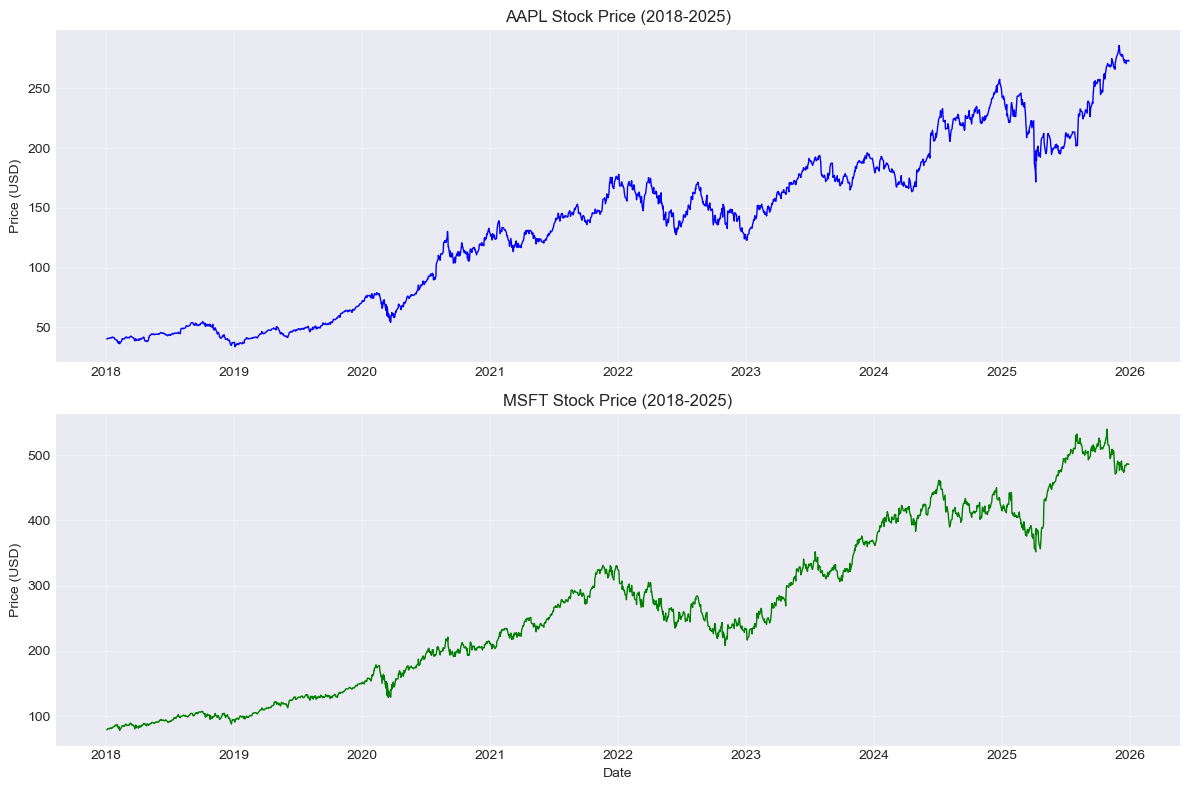

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(prices.index, prices['AAPL'], color='blue', linewidth=1)
axes[0].set_title('AAPL Stock Price (2018-2025)', fontsize=12)
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(prices.index, prices['MSFT'], color='green', linewidth=1)
axes[1].set_title('MSFT Stock Price (2018-2025)', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<h3><b>Plot Description</b></h3>

<p>
Both series exhibit upward trends with significant volatility, particularly during the COVID-19 pandemic (2020) 
and the 2022 bear market. The non-stationary nature is visually evident.
</p>


<h3><b>3.2 Normalized Price Comparison</b></h3>

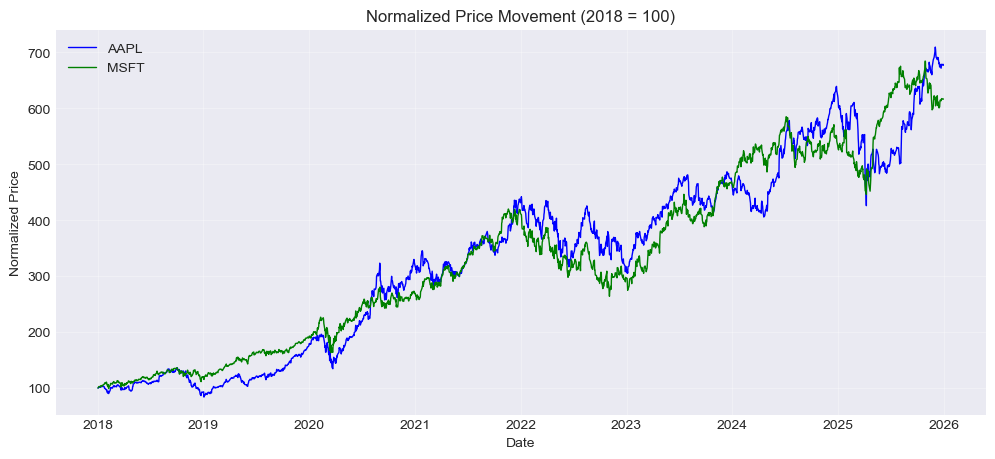

In [25]:
normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 5))
plt.plot(normalized.index, normalized['AAPL'], label='AAPL', color='blue', linewidth=1)
plt.plot(normalized.index, normalized['MSFT'], label='MSFT', color='green', linewidth=1)
plt.title('Normalized Price Movement (2018 = 100)', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<h3><b>Plot Description:</b></h3>
<p>  
MSFT has outperformed AAPL over the sample period, with the gap widening notably after 2023, coinciding with the AI-driven market rally.
</p>

<h3><b>3.3 Equilibrium Spread</b></h3>

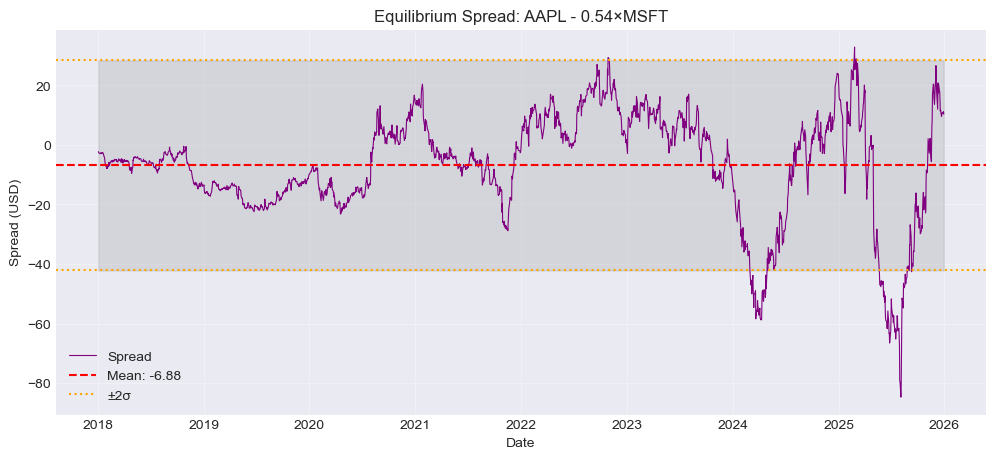

In [26]:
spread = prices['AAPL'] - 0.5397 * prices['MSFT']
spread_mean = spread.mean()
spread_std = spread.std()

plt.figure(figsize=(12, 5))
plt.plot(spread.index, spread, color='purple', linewidth=0.8, label='Spread')
plt.axhline(y=spread_mean, color='red', linestyle='--', label=f'Mean: {spread_mean:.2f}')
plt.axhline(y=spread_mean + 2*spread_std, color='orange', linestyle=':', label='±2σ')
plt.axhline(y=spread_mean - 2*spread_std, color='orange', linestyle=':')
plt.fill_between(spread.index, spread_mean + 2*spread_std, spread_mean - 2*spread_std, 
                 alpha=0.2, color='gray')
plt.title('Equilibrium Spread: AAPL - 0.54×MSFT', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Spread (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


<h3><b>Figure 3.3</b></h3>

<p>
Figure 4.3 shows the equilibrium spread calculated using the estimated cointegrating coefficient 
β = -0.5397 from the VECM. When the spread deviates beyond ±2 standard deviations, the VECM predicts 
mean reversion via the negative adjustment coefficients.
</p>



<h2>4. Diagnosis (Diagnostic Plots)</h2>

<h3><b>4.1 Residuals Over Time</b></h3>


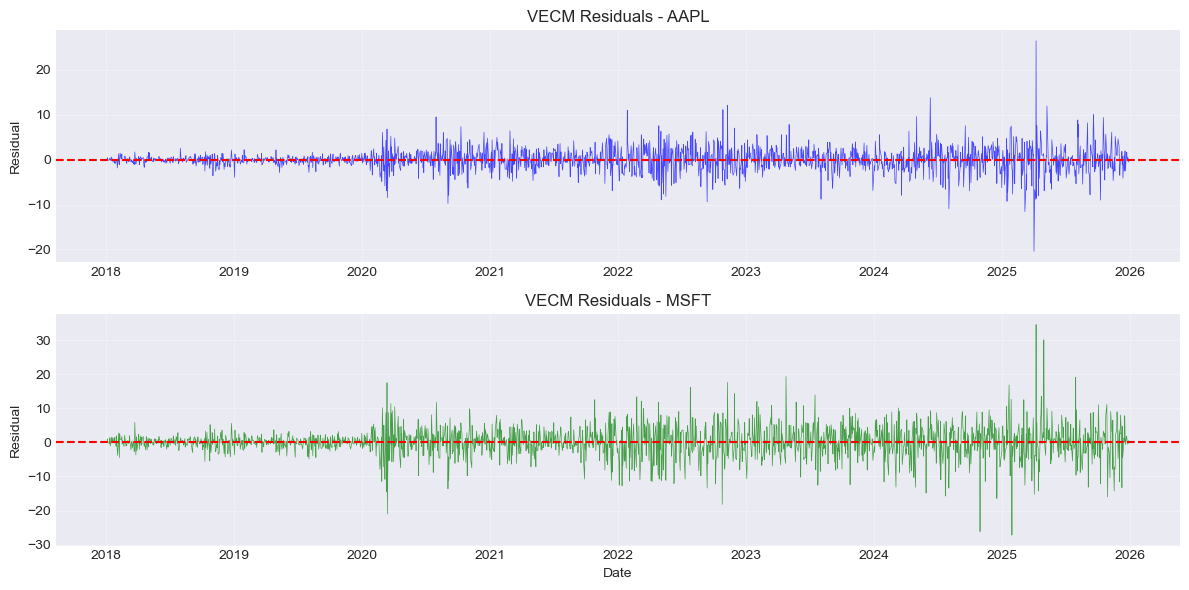

In [30]:

resid = vecm_fit.resid

resid_dates = prices.index[1:len(resid)+1]  # Align dates with residuals

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# AAPL residuals
axes[0].plot(resid_dates, resid[:,0], color='blue', alpha=0.7, linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('VECM Residuals - AAPL', fontsize=12)
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

# MSFT residuals
axes[1].plot(resid_dates, resid[:,1], color='green', alpha=0.7, linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('VECM Residuals - MSFT', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<h3><b>Plot Description</b></h3>
<p>
Residuals appear randomly distributed around zero but show volatility clustering during crisis periods (2020, 2022).
</p>


<h3><b>4.2 Residual Histogram and Q-Q Plot</b></h3>


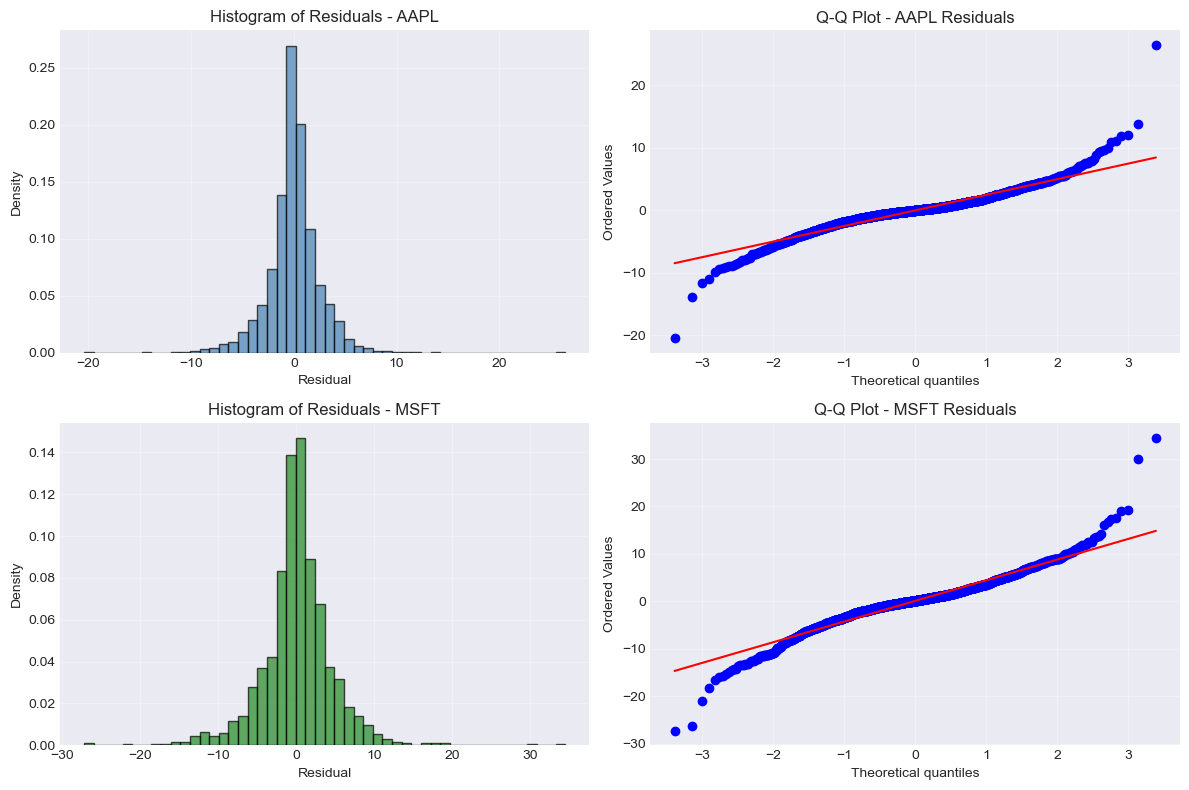

In [32]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row 1: AAPL
# Histogram - AAPL
axes[0,0].hist(resid[:,0], bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
axes[0,0].set_title('Histogram of Residuals - AAPL', fontsize=12)
axes[0,0].set_xlabel('Residual')
axes[0,0].set_ylabel('Density')
axes[0,0].grid(True, alpha=0.3)

# Q-Q Plot - AAPL
stats.probplot(resid[:,0].flatten(), dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot - AAPL Residuals', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Row 2: MSFT
# Histogram - MSFT
axes[1,0].hist(resid[:,1], bins=50, color='forestgreen', edgecolor='black', alpha=0.7, density=True)
axes[1,0].set_title('Histogram of Residuals - MSFT', fontsize=12)
axes[1,0].set_xlabel('Residual')
axes[1,0].set_ylabel('Density')
axes[1,0].grid(True, alpha=0.3)

# Q-Q Plot - MSFT
stats.probplot(resid[:,1].flatten(), dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot - MSFT Residuals', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<p><b>Plot Description:</b> The histograms show residual distributions centered near zero with moderate symmetry. 
The Q-Q plots reveal deviations from the diagonal line, particularly in the tails, indicating that the residuals are not 
perfectly normally distributed. This is typical for financial returns data, which exhibit excess kurtosis (fat tails). 
While non-normality does not bias coefficient estimates, it affects statistical inference (p-values, confidence intervals).</p>



<h2>5. Damage</h2>

<h3><b>Problems Revealed by the Model:</b></h3>

<p>
The model's borderline cointegration result (p = 0.0604) indicates that AAPL and MSFT do not share a stable long-run equilibrium over 2018-2025. 
The relationship is time-varying, likely due to divergent business models (hardware vs. cloud/software) and structural breaks (AI revolution benefiting MSFT disproportionately).
</p>



<h2>6. Damage</h2>

<h3><b>Problems Revealed by the Model</b></h3>

<h3><b>Six Challenges Assessment</b></h3>

<p><b>Non-stationarity:</b> Yes: Addressed via differencing.</p>
<p><b>Cointegration failure:</b> Yes (borderline): Core model weakness.</p>
<p><b>Non-normality:</b> Yes: Affects hypothesis testing.</p>
<p><b>Heteroskedasticity:</b> Yes: Suggests GARCH extension.</p>
<p><b>Autocorrelation:</b> No Minimal: Model adequate.</p>
<p><b>Structural breaks:</b> Yes: Requires regime detection.</p>

<h3><b>Primary Damage Conclusion</b></h3>

<p>
The model's borderline cointegration result (p = 0.0604) indicates that AAPL and MSFT do not share a stable long-run equilibrium over 2018-2025. 
The relationship is time-varying, likely due to divergent business models (hardware vs. cloud/software) and structural breaks 
(AI revolution benefiting MSFT disproportionately).
</p>



<h2>6. Directions</h2>

<h3><b>Recommended Model Improvements</b></h3>

<h4><b>Priority 1 (Data Manipulation):</b></h4>
<ul>
    <li>Remove COVID-19 crisis period (March-May 2020)</li>
    <li>Use log prices instead of raw prices (stabilizes variance)</li>
    <li>Apply 20-day rolling average to reduce noise</li>
</ul>

<h4><b>Priority 2 (Model Specification):</b></h4>
<ul>
    <li>Increase lag length (AIC selected 1; try 2-4)</li>
    <li>Add exogenous variables (VIX, interest rates)</li>
    <li>Use threshold VECM for asymmetric adjustment</li>
</ul>

<h4><b>Priority 3 (Alternative Approaches):</b></h4>
<ul>
    <li>Try better cointegrated pair</li>
    <li>Apply rolling window cointegration (60-day window)</li>
    <li>Use regime-switching VECM (Markov switching)</li>
</ul>



<h2>7. Deployment</h2>

<h3><b>Pairs Trading Strategy Using VECM</b></h3>

<h4><b>Strategy Overview:</b></h4>
<ul>
    <li><b>Asset Pair:</b> Long/Short AAPL and MSFT</li>
    <li><b>Trade Type:</b> Dollar-neutral pairs trade</li>
    <li><b>Expected Hold Time:</b> 5-10 trading days</li>
</ul>

<h4><b>Entry Rules:</b></h4>
<table border="1" cellpadding="6">
    <tr>
        <th>Condition</th>
        <th>Action</th>
    </tr>
    <tr>
        <td>z-score &lt; -2</td>
        <td>BUY AAPL, SELL MSFT (AAPL undervalued)</td>
    </tr>
    <tr>
        <td>z-score &gt; +2</td>
        <td>SELL AAPL, BUY MSFT (AAPL overvalued)</td>
    </tr>
</table>

<h4><b>Exit Rules:</b></h4>
<ul>
    <li>Close position when z-score returns to 0 (mean reversion)</li>
    <li>Stop loss: exit if z-score exceeds ±3</li>
    <li>Time stop: close after 20 days</li>
</ul>

<h4><b>Risk Management:</b></h4>
<ul>
    <li>Maximum pair exposure: 15% of portfolio</li>
    <li>Daily loss limit: 2% of position value</li>
    <li>Margin requirement: ~50% of short position</li>
</ul>

<h4><b>Deployment Infrastructure:</b></h4>
<ul>
    <li>Data feed: Daily closing prices (Yahoo Finance)</li>
    <li>Model update: Re-estimate VECM every 60 trading days</li>
    <li>Signal generation: Automated script at market close</li>
    <li>Execution: Broker API (Alpaca, Interactive Brokers)</li>
</ul>

<h4><b>Performance Metrics to Track:</b></h4>
<ul>
    <li>Sharpe ratio (target &gt; 1.0)</li>
    <li>Maximum drawdown (keep &lt; 10%)</li>
    <li>Win rate (target &gt; 55%)</li>
    <li>Average holding period</li>
</ul>

<h4><b>Caution:</b></h4>
<p>
Due to borderline cointegration (p = 0.0604), consider:
</p>

<ul>
    <li>Wider entry threshold (±2.5σ)</li>
    <li>Smaller position sizing (5% instead of 10%)</li>
    <li>Regular model re-estimation (monthly)</li>
</ul>



<h2>8. Bibliography</h2>

<p>
Engle, Robert F., and Clive W. J. Granger. "Co-Integration and Error Correction: Representation, Estimation, and Testing." 
<i>Econometrica</i>, vol. 55, no. 2, 1987, pp. 251-276.
</p>

<p>
Johansen, Søren. "Estimation and Hypothesis Testing of Cointegration Vectors in Gaussian Vector Autoregressive Models." 
<i>Econometrica</i>, vol. 59, no. 6, 1991, pp. 1551-1580.
</p>

<p>
Tsay, Ruey S. <i>Analysis of Financial Time Series</i>. 3rd ed., Wiley, 2010.
</p>

<p>
Yahoo Finance. "Apple Inc. (AAPL) Historical Prices." Yahoo!, 2026, 
finance.yahoo.com/quote/AAPL/history/.
</p>

<p>
Yahoo Finance. "Microsoft Corporation (MSFT) Historical Prices." Yahoo!, 2026, 
finance.yahoo.com/quote/MSFT/history/.
</p>
